In [1]:
import torch
from tqdm import tqdm
from sbi.inference import SNLE

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import PatchForagingDDM, create_prior

In [2]:
def generate_likelihood_training_data(simulator, prior, num_simulations=10000):
    """
    Generate training data for SNLE.
    
    Returns:
        theta_samples: (N, 3) parameters
        x_samples: (N, 3) summary statistics (normalized)
        x_mean: Mean for denormalization
        x_std: Std for denormalization
    """
    print(f"Generating {num_simulations} training samples...")
    
    theta_samples = []
    x_samples = []
    
    for i in tqdm(range(num_simulations)):
        # Sample parameters
        theta = prior.sample()
        
        # Simulate patch and get summary stats
        global_time = 0.0
        patch_start_time = 0.0
        _, _, summary_stats = simulator._simulate_one_patch(theta, global_time, patch_start_time)
        
        theta_samples.append(theta)
        x_samples.append(summary_stats)
    
    theta_samples = torch.stack(theta_samples)
    x_samples = torch.stack(x_samples)
    
    # Ensure float32
    x_samples = x_samples.float()
    
    # Normalize
    x_mean = x_samples.mean(dim=0, keepdim=True)
    x_std = x_samples.std(dim=0, keepdim=True)
    x_samples_normalized = (x_samples - x_mean) / (x_std + 1e-8)
    
    print(f"Training data shape: theta={theta_samples.shape}, x={x_samples.shape}")
    print(f"Summary stats range (before normalization):")
    print(f"  total_time:  [{x_samples[:, 0].min():.2f}, {x_samples[:, 0].max():.2f}]")
    print(f"  num_stops:   [{x_samples[:, 1].min():.0f}, {x_samples[:, 1].max():.0f}]")
    print(f"  num_rewards: [{x_samples[:, 2].min():.0f}, {x_samples[:, 2].max():.0f}]")
    
    return theta_samples, x_samples_normalized, x_mean, x_std

In [3]:
def train_snle(simulator, prior, num_simulations=10000):
    """
    Train SNLE to learn p(summary_stats | theta) for single patches.
    
    Returns:
        likelihood_estimator: Trained SNLE
        inference: SNLE inference object
        x_mean: Mean of training data (for normalization)
        x_std: Std of training data (for normalization)
    """
    # Generate training data
    theta_samples, x_samples, x_mean, x_std = generate_likelihood_training_data(
        simulator, prior, num_simulations
    )
    
    # Initialize SNLE
    print("\nTraining SNLE...")
    inference = SNLE(prior=prior)
    
    # Add training data
    inference.append_simulations(theta_samples, x_samples)
    
    # Train
    likelihood_estimator = inference.train(
        training_batch_size=50,
        max_num_epochs=50,
        show_train_summary=True
    )
    
    print("SNLE training complete!")
    return likelihood_estimator, inference, x_mean, x_std

In [4]:
def infer_parameters_snle(inference, observed_stats, 
                          x_mean, x_std,
                          num_samples=1000, warmup_steps=200):
    """
    Infer parameters from observed summary statistics using MCMC.
    
    Args:
        inference: Trained SNLE inference object (not just the likelihood estimator)
        observed_stats: (3,) tensor [total_time, num_stops, num_rewards]
        x_mean: Mean used for normalization during training
        x_std: Std used for normalization during training
        num_samples: Number of MCMC samples
        warmup_steps: MCMC warmup steps
    
    Returns:
        posterior_samples: (num_samples, 3) parameter samples
    """
    print("Running MCMC to infer parameters...")
    
    # Normalize observed stats the same way as training data
    observed_stats_normalized = (observed_stats - x_mean.squeeze()) / (x_std.squeeze() + 1e-8)
    
    # Build posterior using the inference object's method
    posterior = inference.build_posterior(
        sample_with="mcmc",
        mcmc_method="slice_np_vectorized",
        mcmc_parameters={
            "num_chains": 1,
            "thin": 5,
            "warmup_steps": warmup_steps,
        }
    )
    
    # Sample from posterior
    posterior_samples = posterior.sample(
        (num_samples,), 
        x=observed_stats_normalized,
        show_progress_bars=True
    )
    
    return posterior_samples

In [5]:
torch.manual_seed(0)
    
# Setup
simulator = PatchForagingDDM()
prior = create_prior()

print("="*60)
print("SNLE TRAINING FOR PATCH-LEVEL INFERENCE")
print("="*60)

# Train SNLE - now returns 4 values including x_mean and x_std
likelihood_estimator, inference, x_mean, x_std = train_snle(
    simulator, prior, num_simulations=100000
)

print("\n" + "="*60)
print("TESTING INFERENCE")
print("="*60)

SNLE TRAINING FOR PATCH-LEVEL INFERENCE
Generating 20000 training samples...


100%|██████████| 20000/20000 [00:03<00:00, 6354.21it/s]


Training data shape: theta=torch.Size([20000, 3]), x=torch.Size([20000, 3])
Summary stats range (before normalization):
  total_time:  [0.49, 1602.37]
  num_stops:   [1, 1586]
  num_rewards: [0, 50]

Training SNLE...
 Training neural network. Epochs trained: 22

KeyboardInterrupt: 

In [ ]:
# Test on a simulated patch
true_theta = torch.tensor([0.6, 0.4, 0.3])
print(f"\nTrue parameters: {true_theta}")

# Simulate observed patch
global_time = 0.0
patch_start_time = 0.0
_, _, observed_stats = simulator._simulate_one_patch(
    true_theta, global_time, patch_start_time
)
print(f"Observed summary stats: {observed_stats}")
print(f"  - Total time: {observed_stats[0]:.2f}")
print(f"  - Num stops: {observed_stats[1]:.0f}")
print(f"  - Num rewards: {observed_stats[2]:.0f}")

# Infer parameters - pass inference object, not likelihood_estimator
posterior_samples = infer_parameters_snle(
    inference,
    observed_stats,
    x_mean, x_std,
    num_samples=1000, 
    warmup_steps=200
)

# Analyze results
posterior_mean = posterior_samples.mean(dim=0)
posterior_std = posterior_samples.std(dim=0)

print(f"\nInference results:")
print(f"True parameters:      {true_theta}")
print(f"Posterior mean:       {posterior_mean}")
print(f"Posterior std:        {posterior_std}")
print(f"Absolute error:       {(posterior_mean - true_theta).abs()}")


True parameters: tensor([0.6000, 0.4000, 0.3000])
Observed summary stats: tensor([1.9671, 2.0000, 0.0000])
  - Total time: 1.97
  - Num stops: 2
  - Num rewards: 0
Running MCMC to infer parameters...


Generating 1 MCMC inits via resample strategy:   0%|          | 0/1 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/6050 [00:00<?, ?it/s]


Inference results:
True parameters:      tensor([0.6000, 0.4000, 0.3000])
Posterior mean:       tensor([0.4623, 0.8149, 0.8598])
Posterior std:        tensor([0.2765, 0.4053, 0.3927])
Absolute error:       tensor([0.1377, 0.4149, 0.5598])


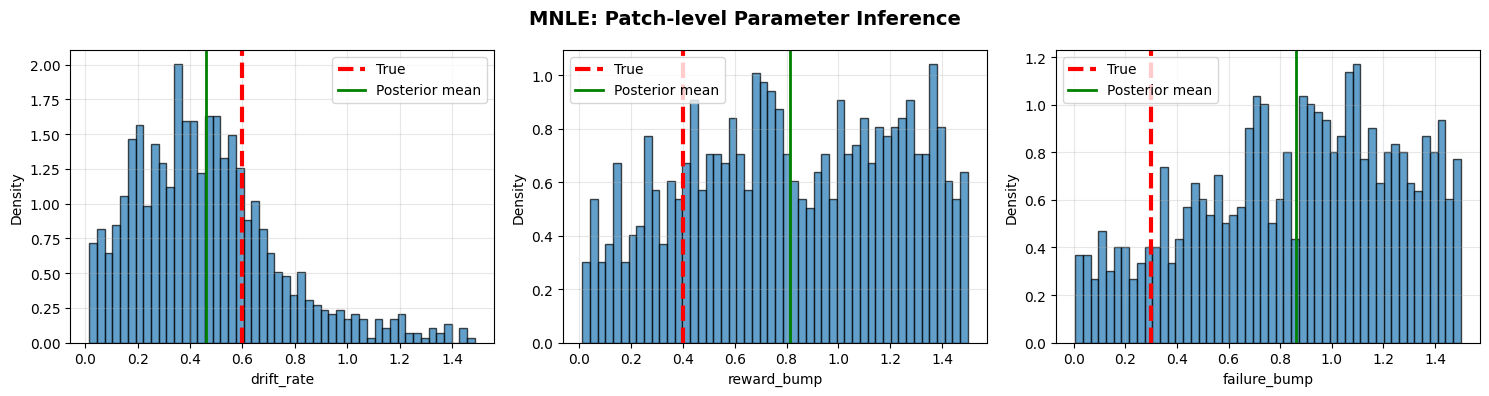

In [9]:
# Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
param_names = ['drift_rate', 'reward_bump', 'failure_bump']

for i, (ax, name) in enumerate(zip(axes, param_names)):
    ax.hist(posterior_samples[:, i].numpy(), bins=50, 
            density=True, alpha=0.7, edgecolor='black')
    ax.axvline(true_theta[i].item(), color='red', 
                linestyle='--', linewidth=3, label='True')
    ax.axvline(posterior_mean[i].item(), color='green', 
                linestyle='-', linewidth=2, label='Posterior mean')
    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('MNLE: Patch-level Parameter Inference', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_77441/1859732144.py:7: DeprecationWarning: you passed deprecated arguments **kwargs: ['kde_offdiag', 'kde_diag', 'contour_offdiag', 'points_colors', 'points_offdiag'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, ax = pairplot(


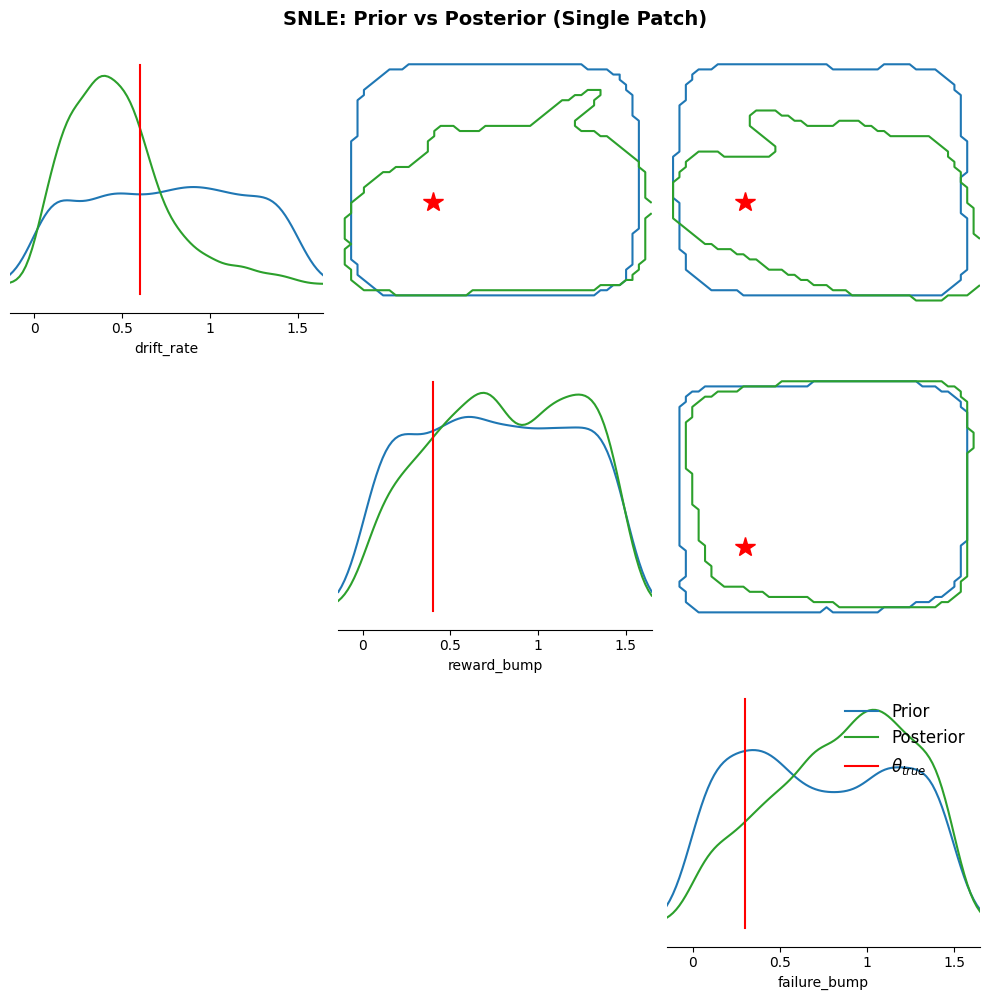

In [10]:
from sbi.analysis import pairplot

# Generate prior samples for comparison
prior_samples = prior.sample((1000,))

# Create pairplot comparing prior and posterior
fig, ax = pairplot(
    [prior_samples, posterior_samples],
    points=true_theta,  # True parameters as a point
    diag="kde",
    upper="contour", 
    kde_offdiag=dict(bins=50),
    kde_diag=dict(bins=100),
    contour_offdiag=dict(levels=[0.95]),
    points_colors=["red"], 
    points_offdiag=dict(marker="*", markersize=15), 
    labels=[r"drift_rate", r"reward_bump", r"failure_bump"],
    figsize=(10, 10)
)

# Add legend
plt.sca(ax[2, 2])  # Select the bottom-right subplot
plt.legend(
    ["Prior", "Posterior", r"$\theta_{true}$"], 
    frameon=False, 
    fontsize=12,
    loc='upper right'
)

plt.suptitle('SNLE: Prior vs Posterior (Single Patch)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


Generating patches from posterior samples for comparison...
Real data shape: torch.Size([100, 3])
Synthetic data shape: torch.Size([100, 3])


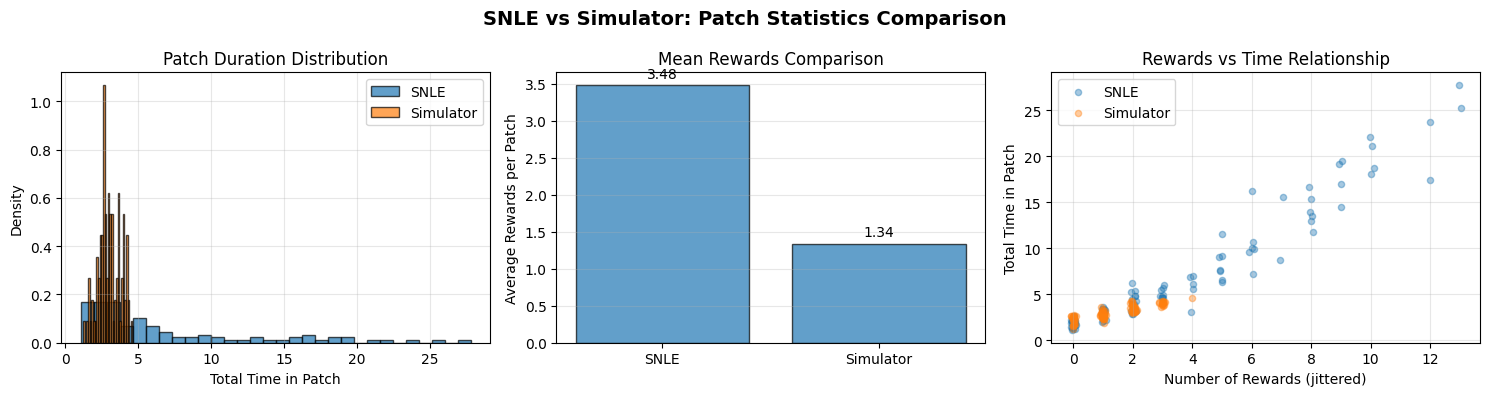


COMPARISON SUMMARY

Total Time in Patch:
  SNLE:      6.936 ± 6.305
  Simulator: 3.010 ± 0.749

Number of Stops:
  SNLE:      7.060 ± 6.267
  Simulator: 2.930 ± 0.902

Number of Rewards:
  SNLE:      3.480 ± 3.540
  Simulator: 1.340 ± 1.047


In [11]:
import numpy as np

# Generate multiple patches from posterior samples to compare distributions
print("\nGenerating patches from posterior samples for comparison...")

num_comparison_patches = 100

# 1. Generate "real" data from true simulator with true parameters
real_patches = []
for _ in range(num_comparison_patches):
    global_time = 0.0
    patch_start_time = 0.0
    _, _, stats = simulator._simulate_one_patch(true_theta, global_time, patch_start_time)
    real_patches.append(stats)
real_data = torch.stack(real_patches)

# 2. Generate "synthetic" data from simulator using posterior-sampled parameters
synthetic_patches = []
for i in range(num_comparison_patches):
    # Sample a parameter from posterior
    theta_sample = posterior_samples[i % len(posterior_samples)]
    
    global_time = 0.0
    patch_start_time = 0.0
    _, _, stats = simulator._simulate_one_patch(theta_sample, global_time, patch_start_time)
    synthetic_patches.append(stats)
synthetic_data = torch.stack(synthetic_patches)

print(f"Real data shape: {real_data.shape}")
print(f"Synthetic data shape: {synthetic_data.shape}")

# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Time in patch distributions
axes[0].hist(synthetic_data[:, 0].numpy(), bins=30, alpha=0.7, label='SNLE', 
             density=True, edgecolor='black')
axes[0].hist(real_data[:, 0].numpy(), bins=30, alpha=0.7, label='Simulator', 
             density=True, edgecolor='black')
axes[0].set_xlabel('Total Time in Patch')
axes[0].set_ylabel('Density')
axes[0].set_title('Patch Duration Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Average rewards comparison
synth_rewards = synthetic_data[:, 2].mean()  # Column 2 is num_rewards
real_rewards = real_data[:, 2].mean()

axes[1].bar(['SNLE', 'Simulator'], [synth_rewards, real_rewards], 
            alpha=0.7, edgecolor='black', capsize=5)
axes[1].set_ylabel('Average Rewards per Patch')
axes[1].set_title('Mean Rewards Comparison')
axes[1].grid(True, alpha=0.3, axis='y')

# Add text labels on bars
for i, (label, value) in enumerate(zip(['SNLE', 'Simulator'], [synth_rewards, real_rewards])):
    axes[1].text(i, value + 0.1, f'{value:.2f}', ha='center', fontsize=10)

# Plot 3: Rewards vs Time scatter
axes[2].scatter(synthetic_data[:, 2].numpy() + np.random.normal(0, 0.05, num_comparison_patches), 
                synthetic_data[:, 0].numpy(), alpha=0.4, label='SNLE', s=20)
axes[2].scatter(real_data[:, 2].numpy() + np.random.normal(0, 0.05, num_comparison_patches), 
                real_data[:, 0].numpy(), alpha=0.4, label='Simulator', s=20)
axes[2].set_xlabel('Number of Rewards (jittered)')
axes[2].set_ylabel('Total Time in Patch')
axes[2].set_title('Rewards vs Time Relationship')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('SNLE vs Simulator: Patch Statistics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"\nTotal Time in Patch:")
print(f"  SNLE:      {synthetic_data[:, 0].mean():.3f} ± {synthetic_data[:, 0].std():.3f}")
print(f"  Simulator: {real_data[:, 0].mean():.3f} ± {real_data[:, 0].std():.3f}")
print(f"\nNumber of Stops:")
print(f"  SNLE:      {synthetic_data[:, 1].mean():.3f} ± {synthetic_data[:, 1].std():.3f}")
print(f"  Simulator: {real_data[:, 1].mean():.3f} ± {real_data[:, 1].std():.3f}")
print(f"\nNumber of Rewards:")
print(f"  SNLE:      {synthetic_data[:, 2].mean():.3f} ± {synthetic_data[:, 2].std():.3f}")
print(f"  Simulator: {real_data[:, 2].mean():.3f} ± {real_data[:, 2].std():.3f}")
print("="*60)